In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import numpy as np
import dataclasses


system_to_color = {}
system_to_color["hnsw_pickle"] = "tab:red"
system_to_color["hnsw_faiss"] = "tab:olive"
system_to_color["hnsw_official"] = "tab:blue"

@dataclasses.dataclass
class Config:
    system: str
    graph: str
    vsize: str
    max_deg: int
    build_ef: int
    k: int
    
    def __init__(self, system, graph, vsize, max_deg, build_ef, k):
        self.system = system
        self.graph = graph
        self.vsize = vsize
        self.max_deg = max_deg
        self.build_ef = build_ef
        self.k = k
        
    def get_log_name(self):
        return f"{self.graph}_{self.vsize}_ef{self.build_ef}_M{self.max_deg}.{self.system}"

    def get_plot_name(self):
        return f"{self.graph}_{self.vsize}_ef{self.build_ef}_M{self.max_deg}_K{self.k}.pdf"
        
    def get_log_path(self):
        return os.path.join('log', self.graph, self.get_log_name())

    def dict(self):
        ret = {}
        ret['graph'] = self.graph
        ret['system'] = self.system
        ret['size'] = self.vsize
        ret['M'] = self.max_deg
        ret['build_ef'] = self.build_ef
        ret['k'] = self.k
        return ret

    def title_meta(self):
        return f"{self.graph}_{self.vsize}_M{self.max_deg}_ef{self.build_ef}_k{self.k}"

def filter_df(config: Config, df):
    # Filter the rows with config
    f_df = df.copy()
    filters: dict = config.dict()
    for key, value in filters.items():
        f_df = f_df[f_df[key] == value]
        
    return f_df

def plot_dist(configs: list[Config]):
    df = pd.read_csv("log.csv")
    plt.figure(figsize=(4, 3))

    for config in configs:
        f_df = filter_df(config, df)
        x = f_df["dist"]
        y = f_df["recall"]
        color = system_to_color[config.system]
        plt.plot(x, y, 'o-', markersize=4, color=color, label=config.system)

    meta = config.title_meta() 
    title = "Recall vs Distance" + "\n" + meta 
    plt.title(title)
    plt.xscale("log")
    plt.xlabel('Distance')
    plt.ylabel('Recall')
    plt.legend()
    plt.tight_layout()
    file_path = f"figs/{meta}_dist.pdf"
    plt.savefig(file_path)
    plt.show()

def plot_qps(configs: list[Config]):
    df = pd.read_csv("log.csv")
    plt.figure(figsize=(4, 3))

    for config in configs:
        f_df = filter_df(config, df)
        y = f_df["qps_t"]
        x = f_df["recall"]
        color = system_to_color[config.system]
        plt.plot(x, y, 'o-', markersize=4, color=color, label=config.system)

    meta = config.title_meta() 
    title = "Recall vs QPS" + "\n" + meta
    plt.title(title)
    plt.yscale("log")
    plt.ylabel('QPS')
    plt.xlabel('Recall')
    plt.legend()
    plt.tight_layout()
    file_path = f"figs/{meta}_qps.pdf"
    plt.savefig(file_path)
    plt.show()

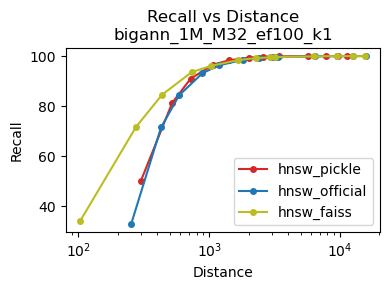

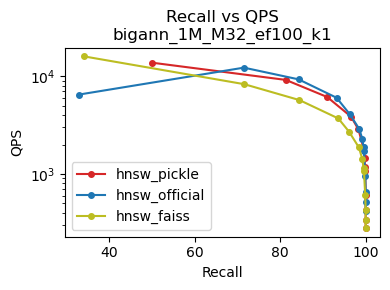

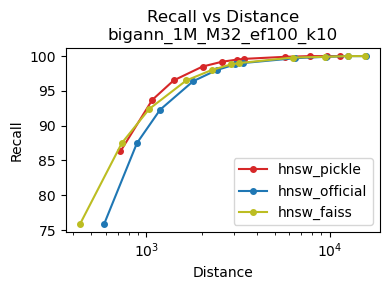

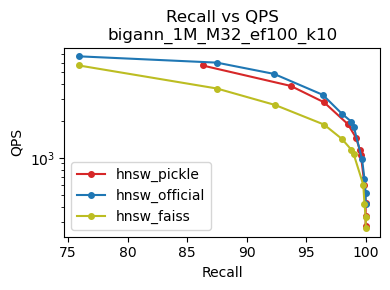

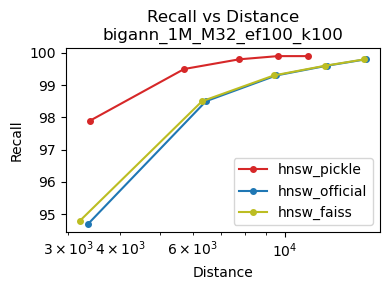

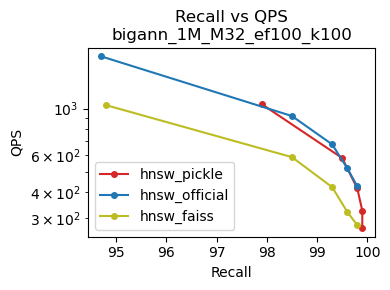

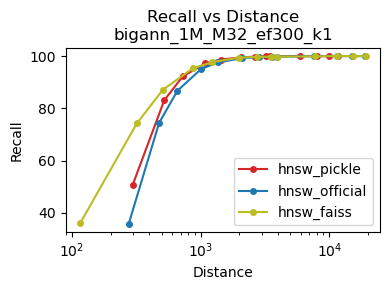

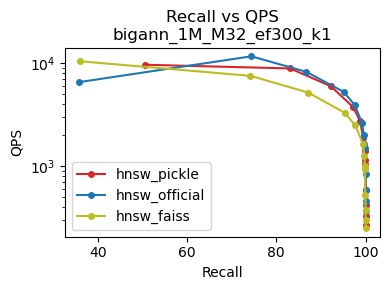

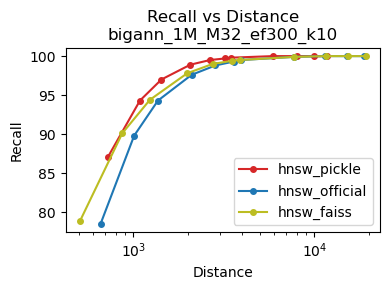

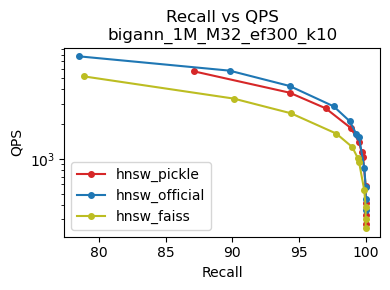

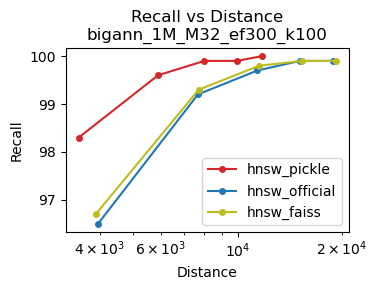

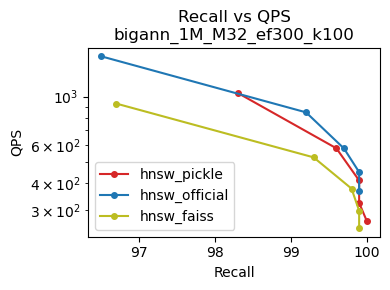

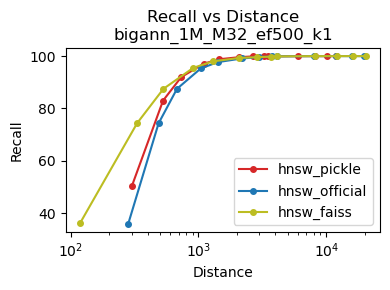

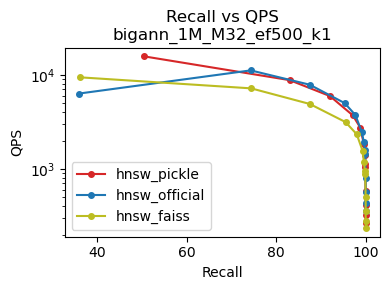

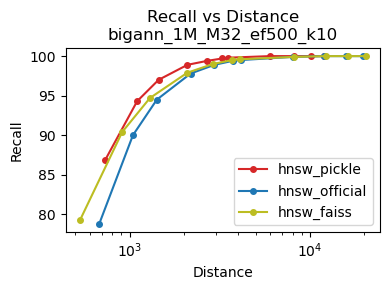

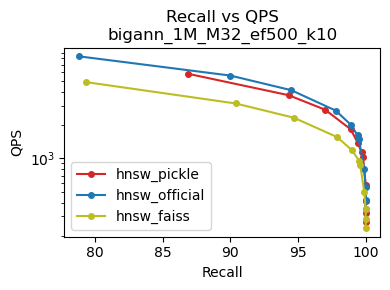

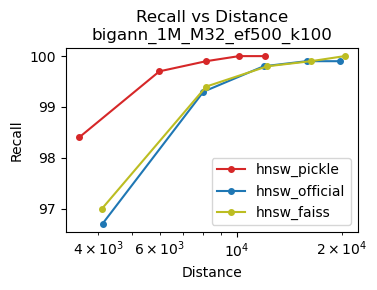

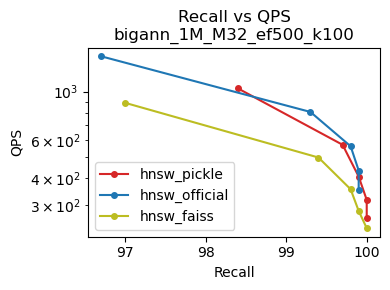

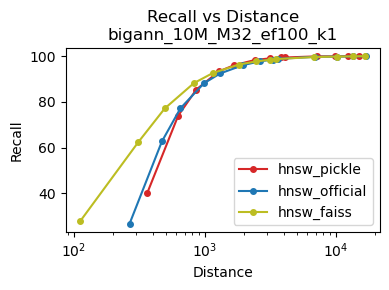

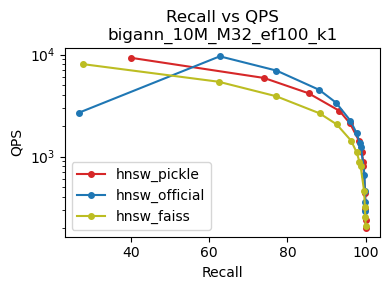

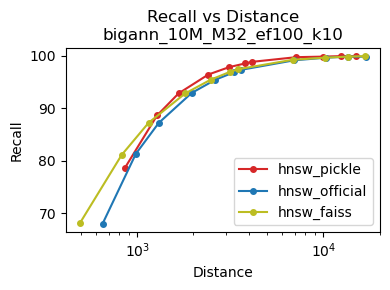

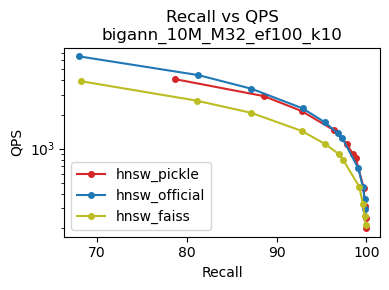

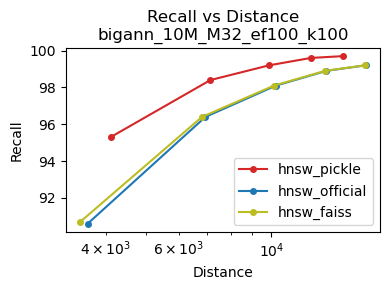

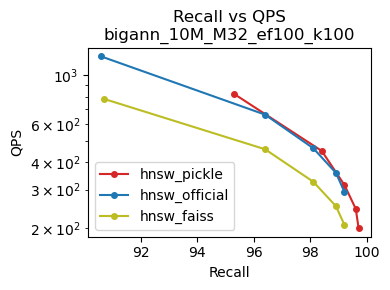

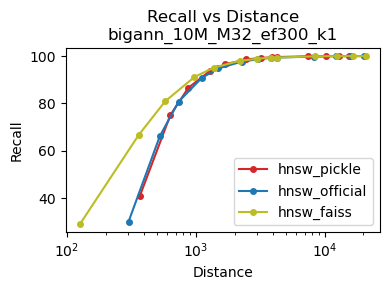

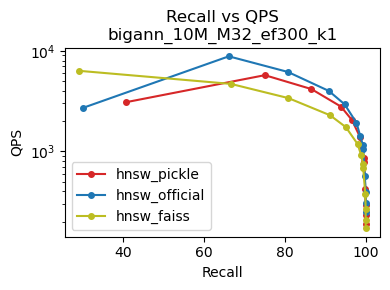

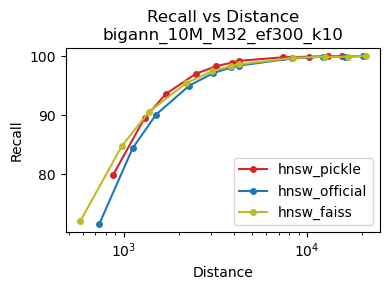

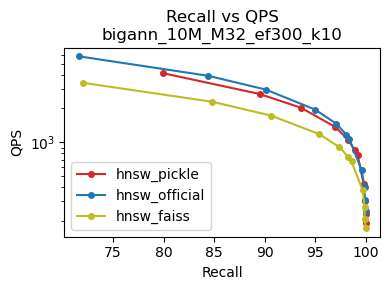

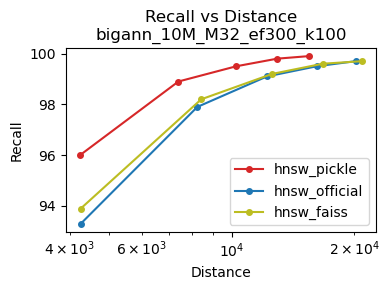

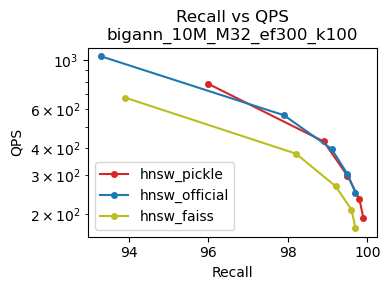

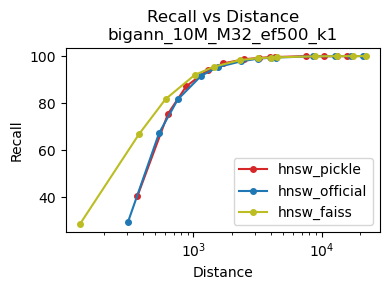

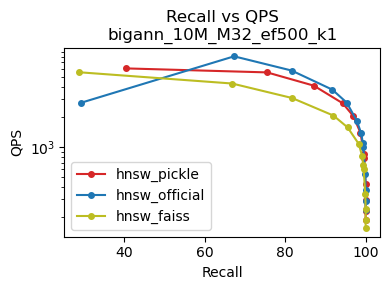

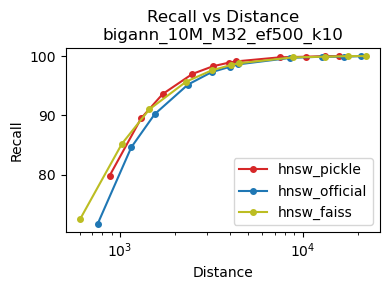

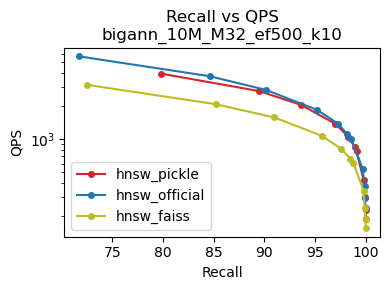

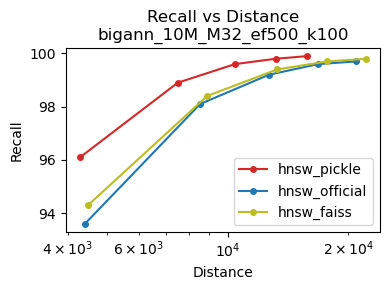

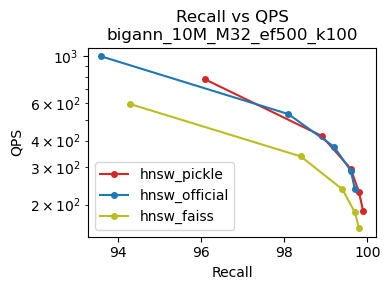

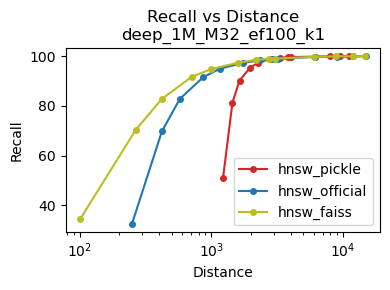

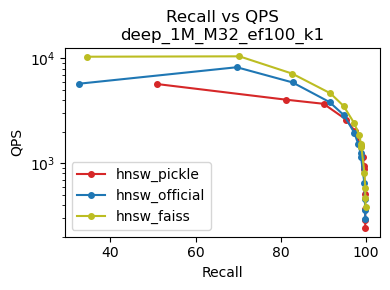

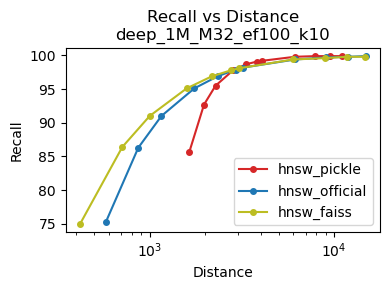

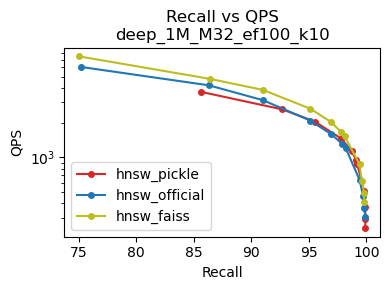

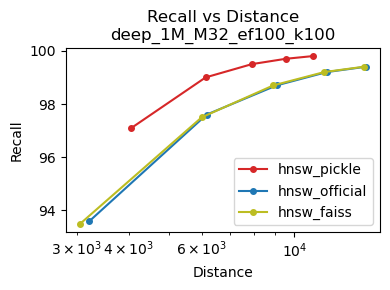

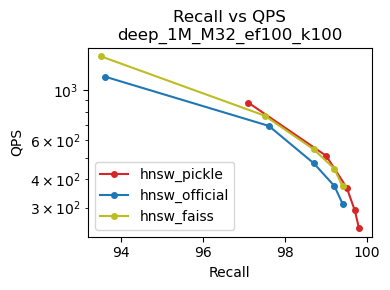

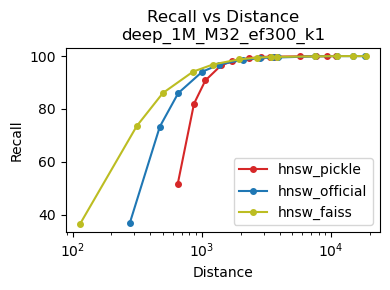

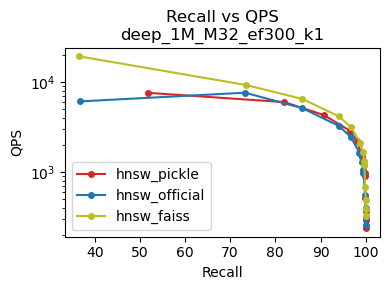

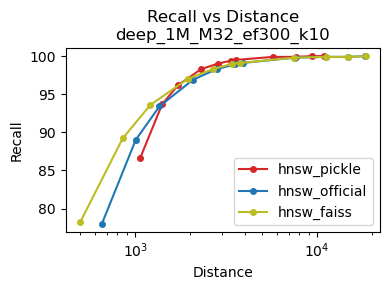

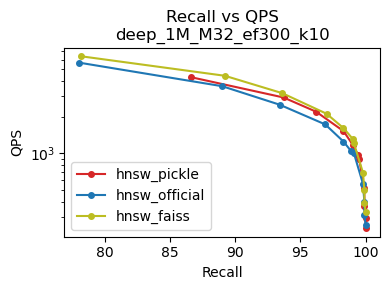

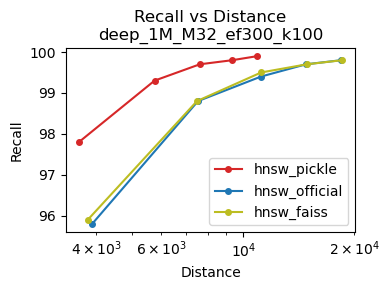

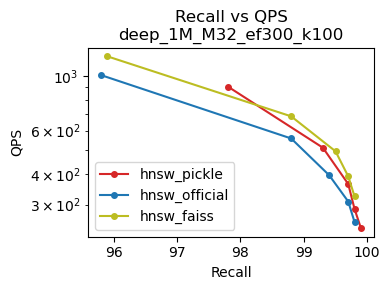

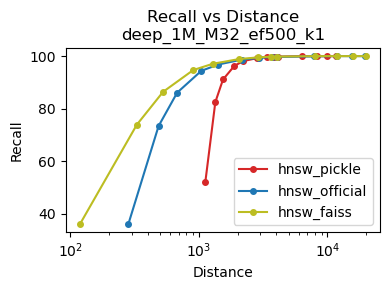

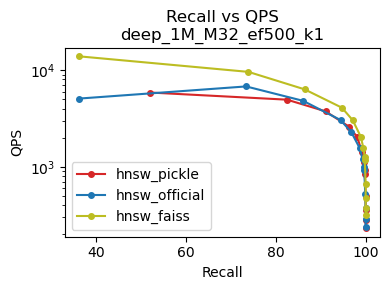

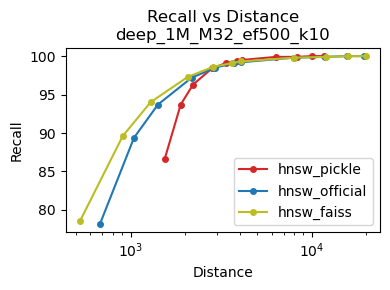

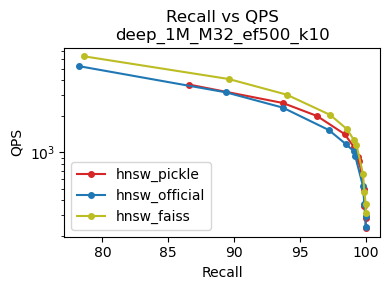

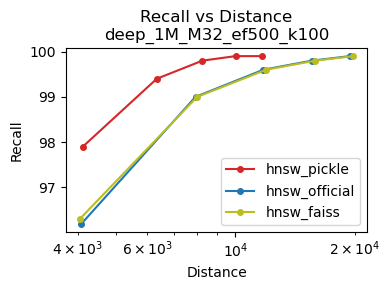

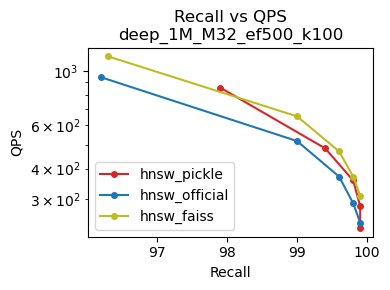

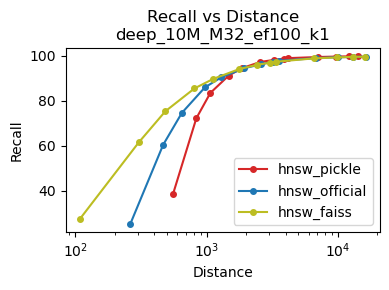

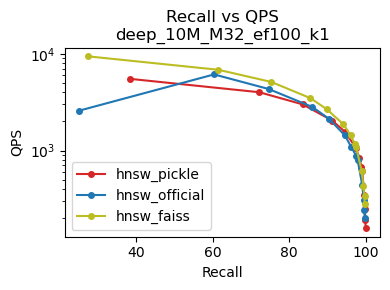

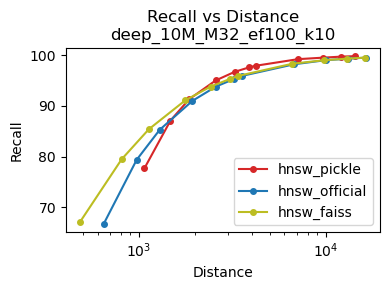

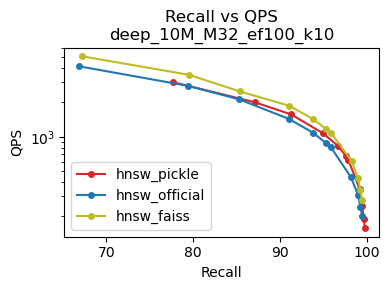

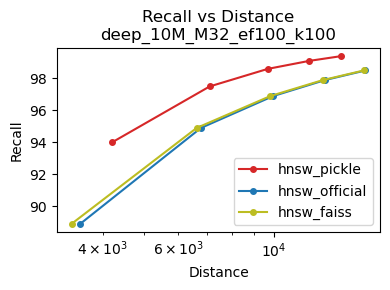

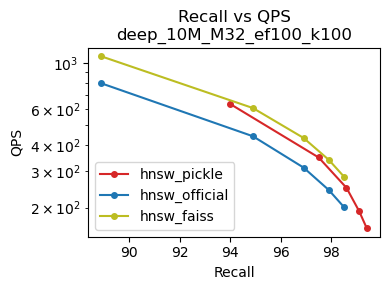

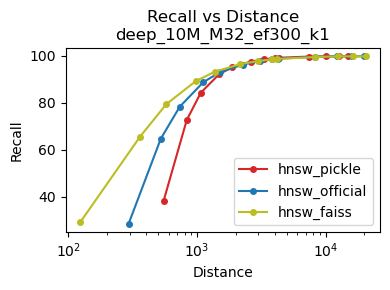

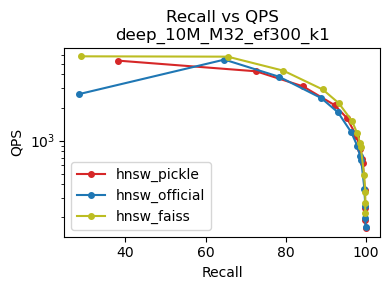

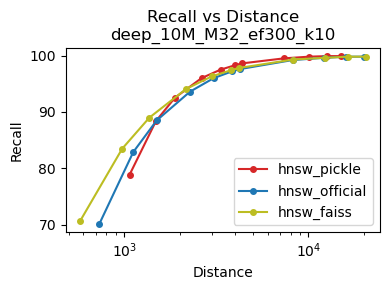

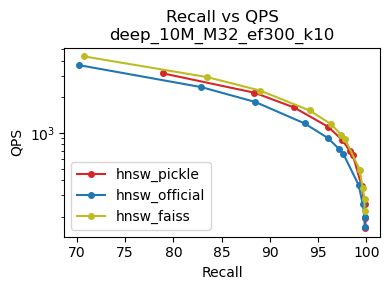

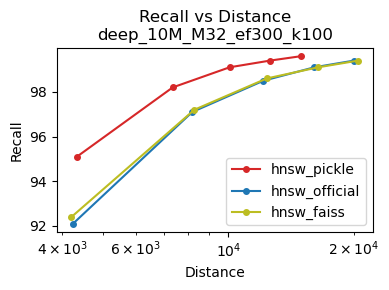

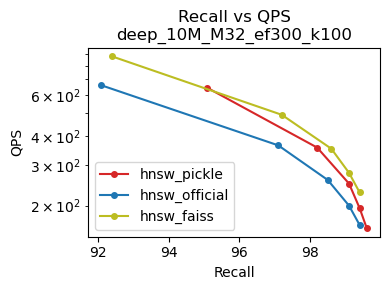

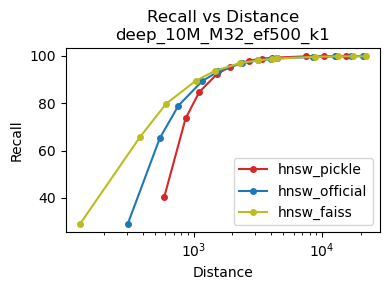

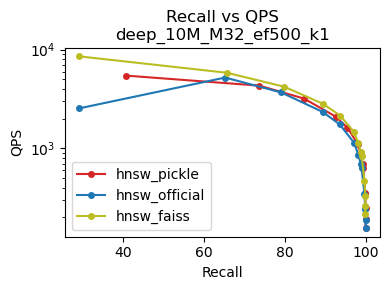

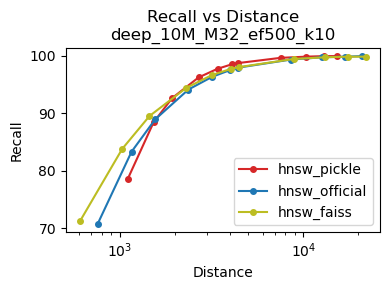

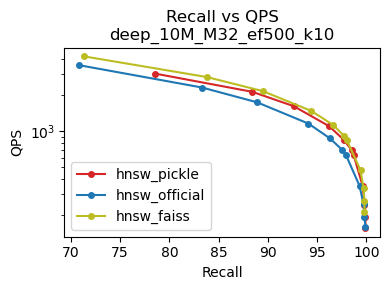

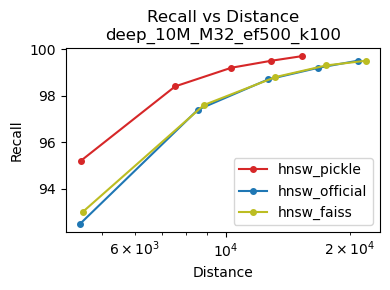

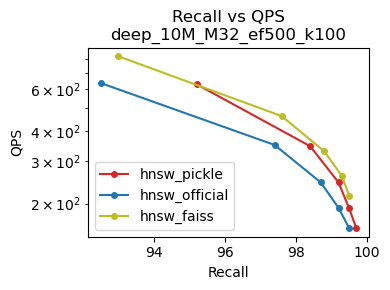

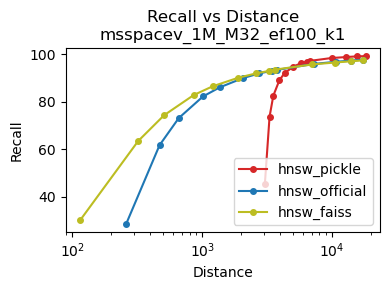

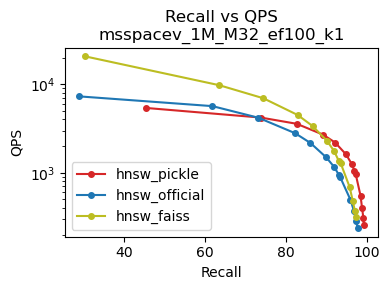

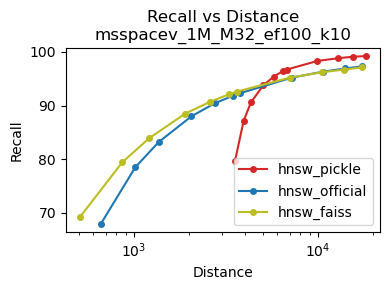

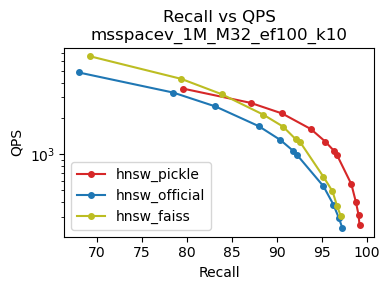

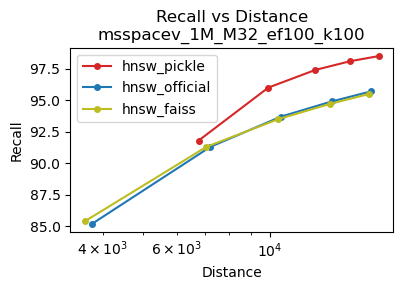

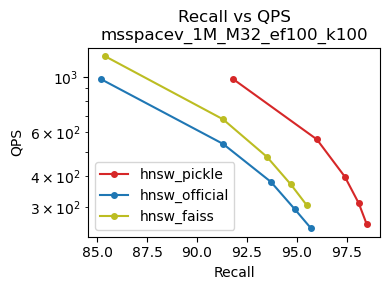

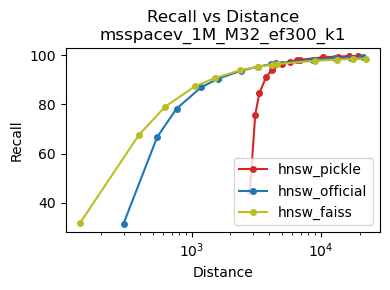

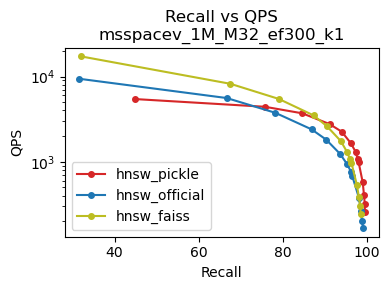

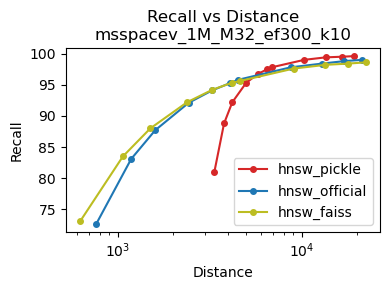

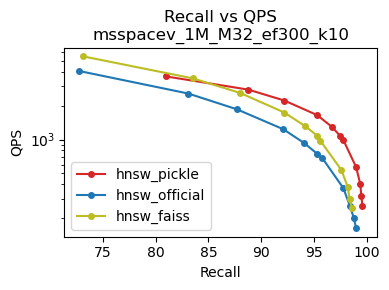

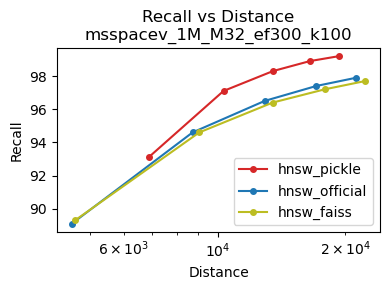

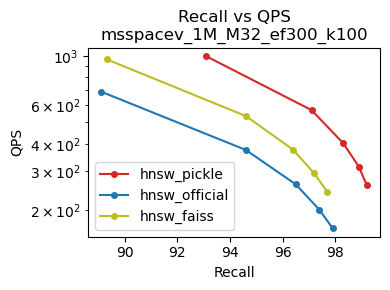

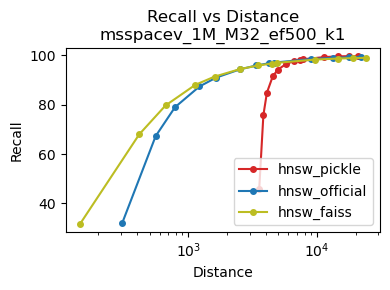

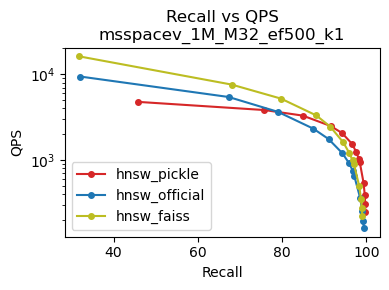

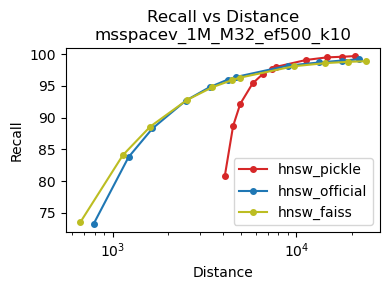

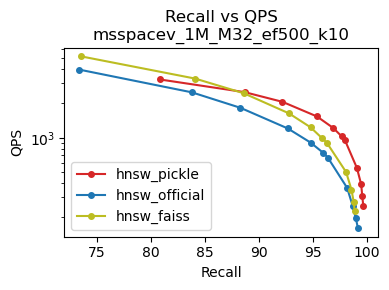

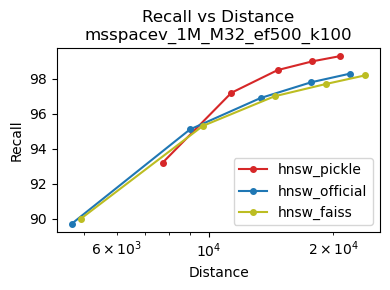

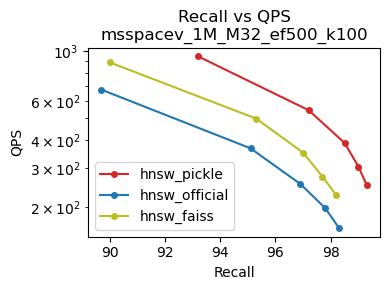

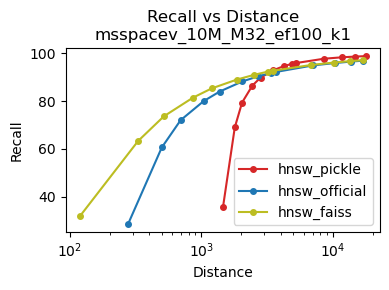

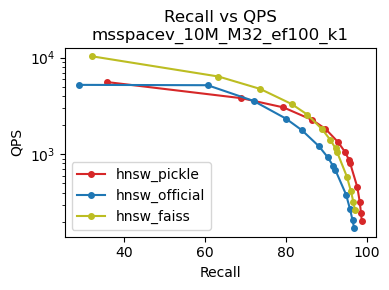

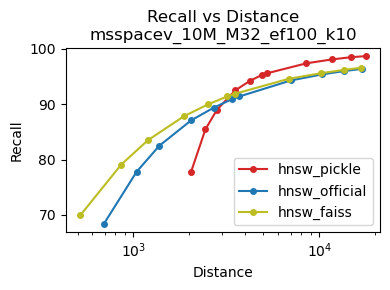

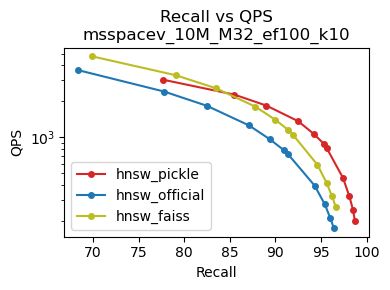

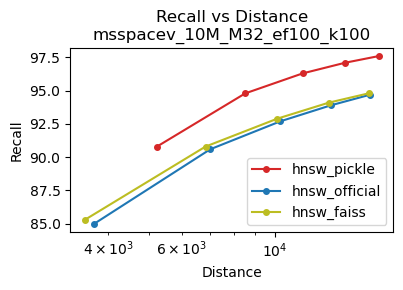

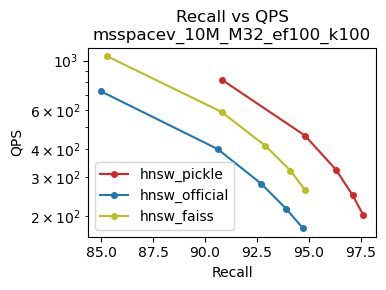

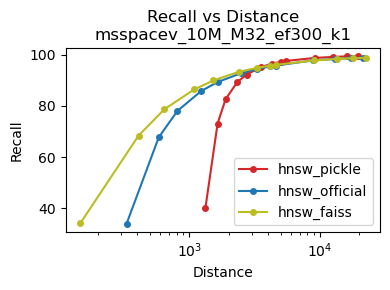

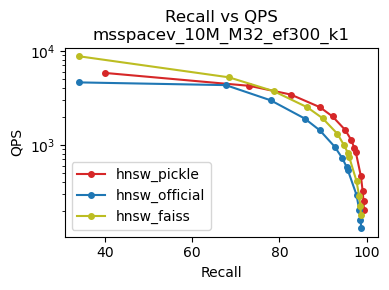

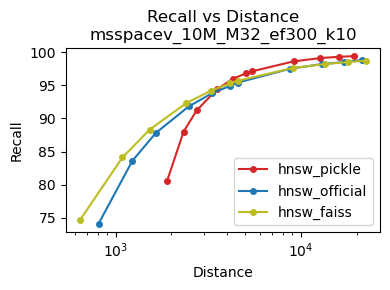

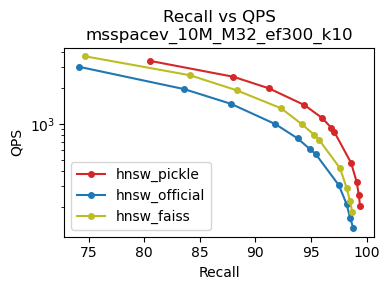

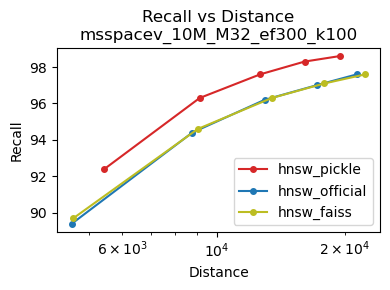

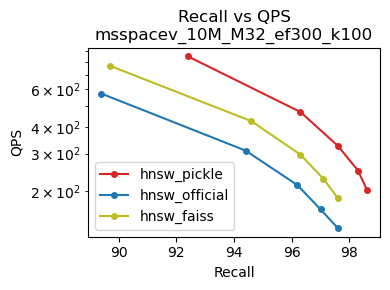

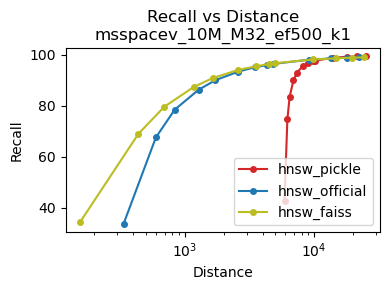

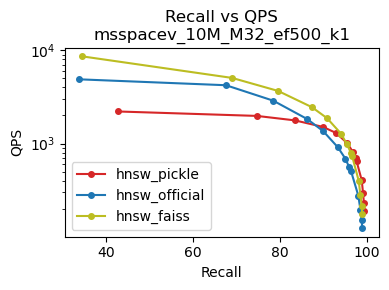

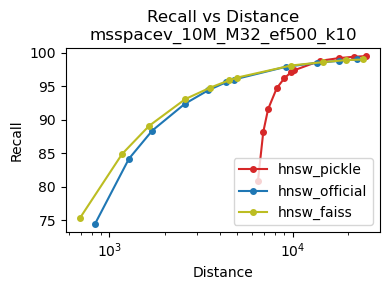

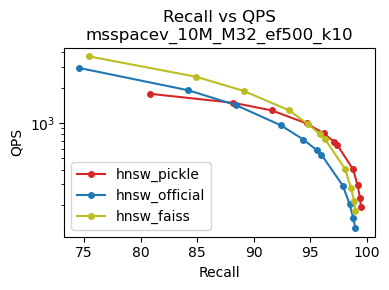

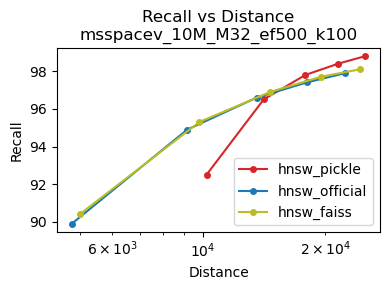

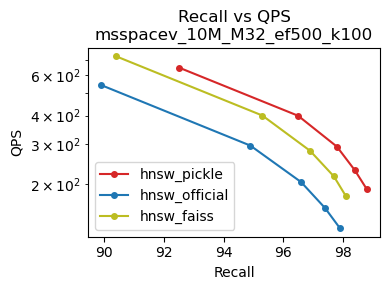

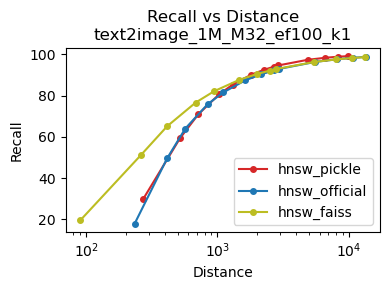

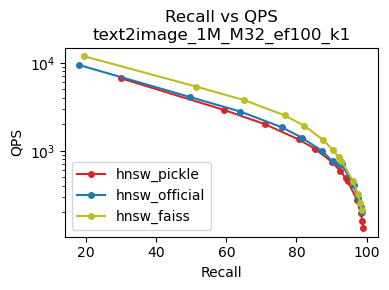

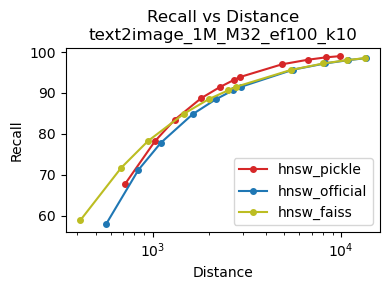

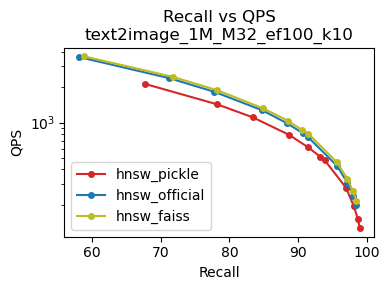

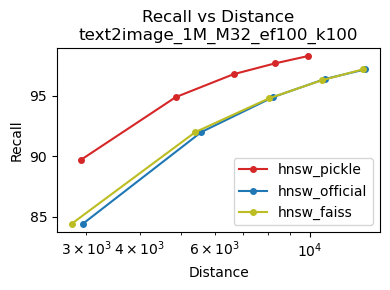

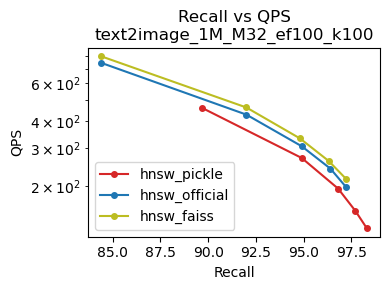

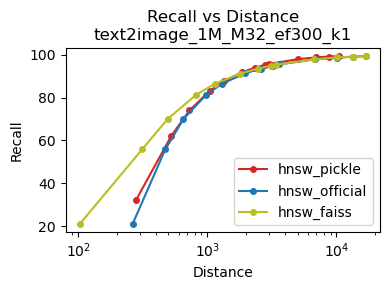

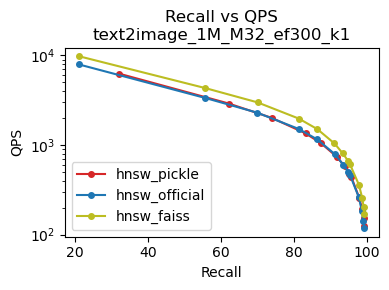

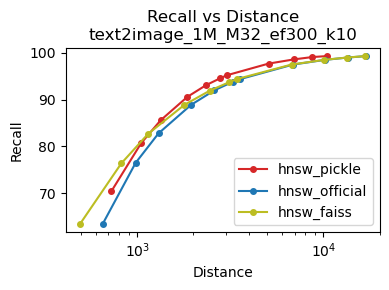

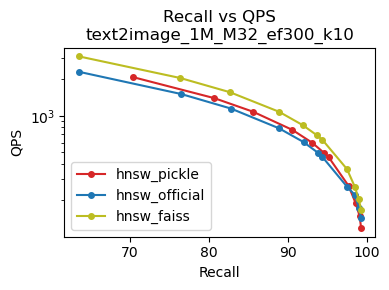

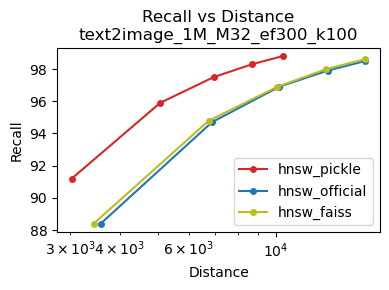

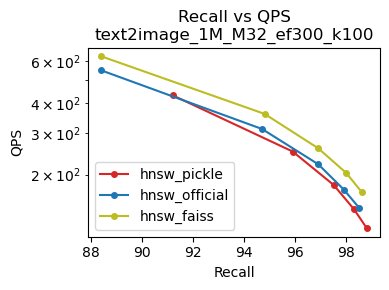

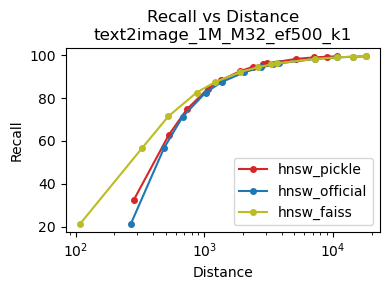

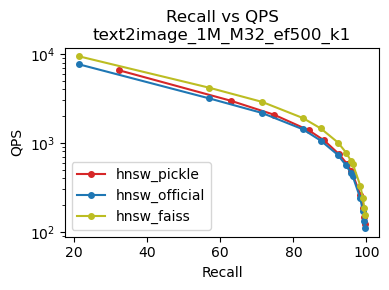

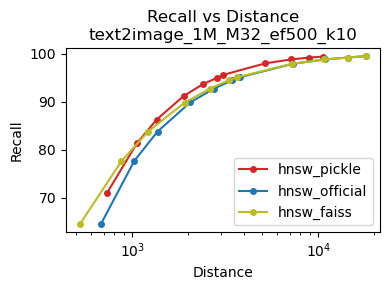

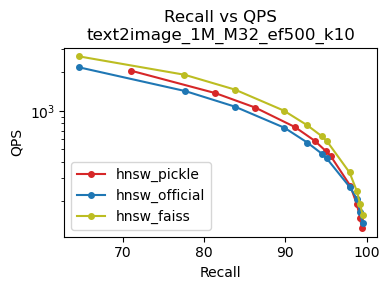

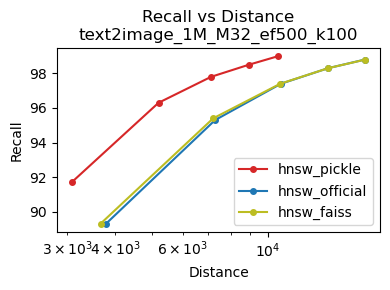

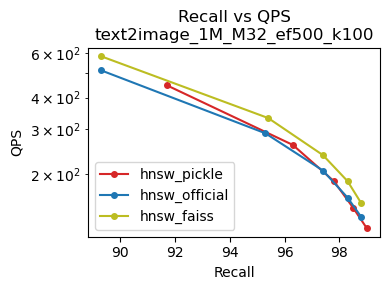

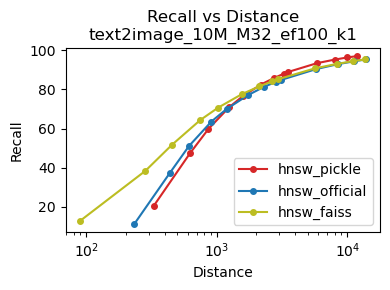

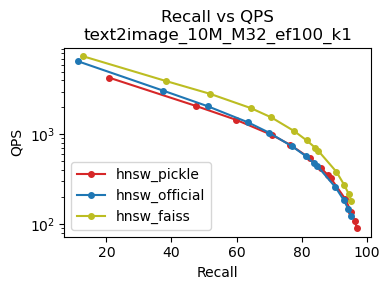

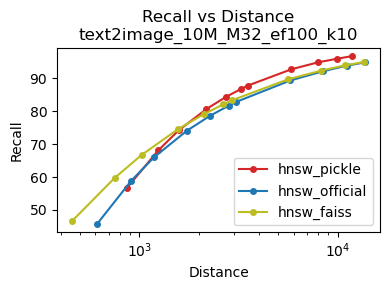

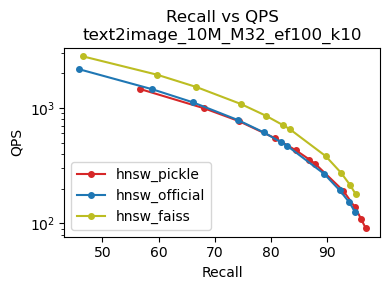

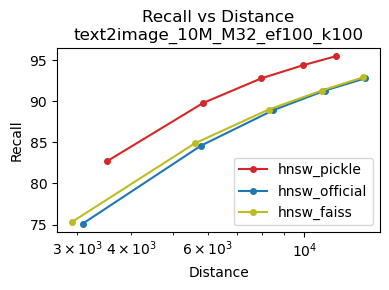

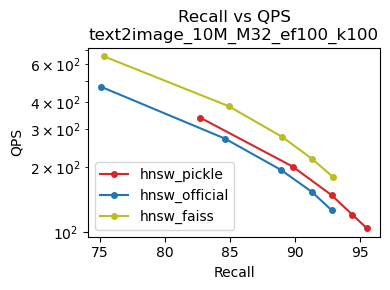

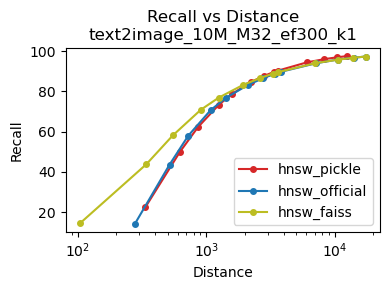

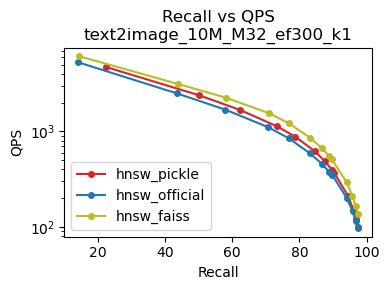

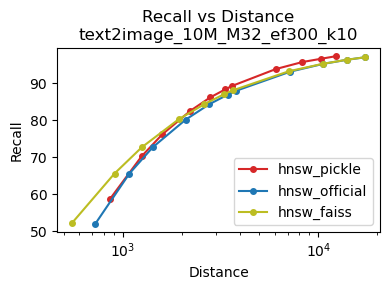

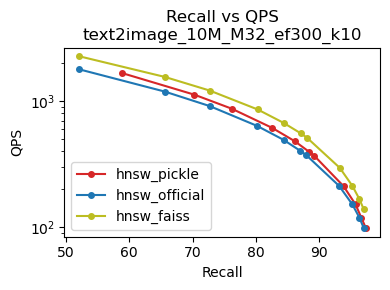

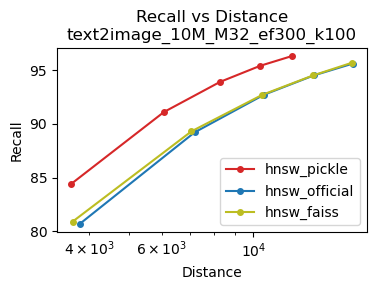

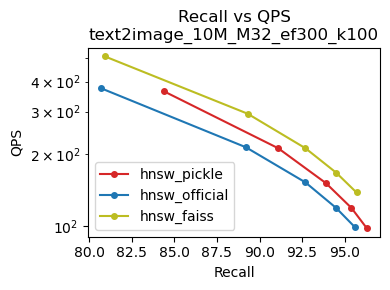

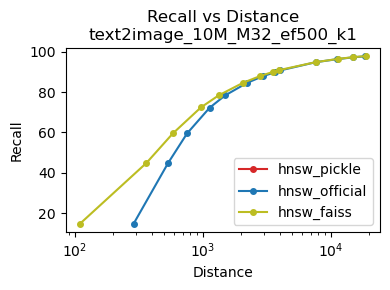

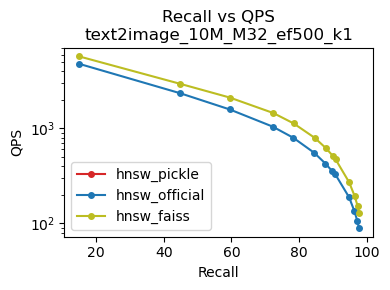

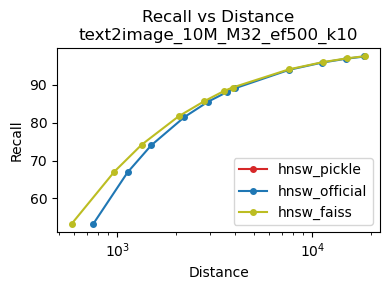

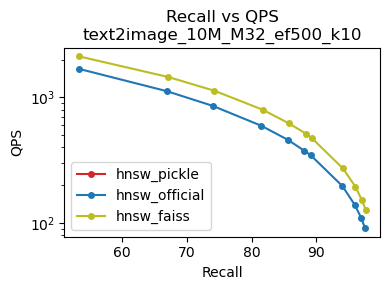

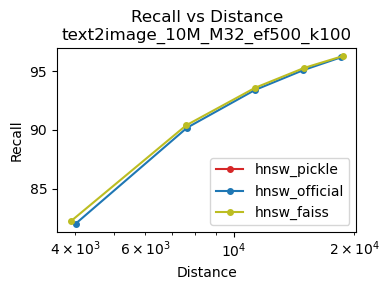

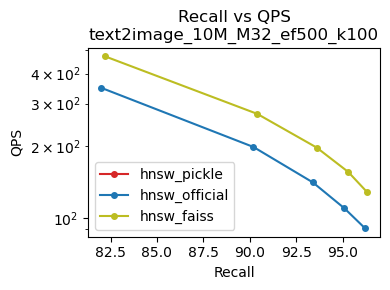

In [2]:
for graph in ["bigann", "deep", "msspacev", "text2image"]:
    for vsize in ["1M", "10M"]:
        for build_ef in [100, 300, 500]:
            for top_k in [1, 10, 100]:
                configs = []
                for system in ["hnsw_pickle", "hnsw_official", "hnsw_faiss"]:
                    config = Config(system, graph, vsize, max_deg, build_ef, top_k)
                    configs.append(config)
                plot_dist(configs)
                plot_qps(configs)